# Problem 21 — Amicable Numbers

Let d(n) be defined as the sum of proper divisors of n (numbers less than n which divide evenly into n).
If d(a) = b and d(b) = a, where a ≠ b, then a and b are an amicable pair and each of a and b are called amicable numbers.

For example, the proper divisors of 220 are 1, 2, 4, 5, 10, 11, 20, 22, 44, 55 and 110; therefore d(220) = 284. The proper divisors of 284 are 1, 2, 4, 71 and 142; so d(284) = 220.

Evaluate the sum of all the amicable numbers under 10000.

In [41]:
def find_sum_proper_divisors(n):
    divisors = [1]
    for i in range(2,int(n**0.5)+1):
        if n % i == 0:
            divisors.append(i)
            if i != n // i:
                divisors.append(n // i)
    return sum(divisors)

amicable_nr = []
for i in range(1, 10001):
    a = find_sum_proper_divisors(i)
    b = find_sum_proper_divisors(a)
    if b == i and a != b:
        amicable_nr.extend([a,b])

amicable_nr = list(dict.fromkeys(amicable_nr))
print(sum(amicable_nr))

31626


# Problem 22 — Names Scores

Using [names.txt](https://projecteuler.net/resources/documents/0022_names.txt), a 46K text file containing over five-thousand first names, begin by sorting it into alphabetical order. Then working out the alphabetical value for each name, multiply this value by its alphabetical position in the list to obtain a name score.

For example, when the list is sorted into alphabetical order, COLIN, which is worth 3 + 15 + 12 + 9 + 14 = 53, is the 938th name in the list. So, COLIN would obtain a score of 938 × 53 = 49714.

What is the total of all the name scores in the file?

In [150]:
f = open("0022_names.txt")
content = f.read()
raw_content = content.split(",")
import re
names = []
for element in raw_content:
    name = re.sub(r'[^a-zA-Z0-9]', '', element)
    names.append(name)
names.sort()

char_codex = {'a':1, 'b':2, 'c':3, 'd':4, 'e':5, 'f':6,
              'g':7, 'h':8, 'i':9, 'j':10, 'k':11, 'l':12, 
              'm':13, 'n':14, 'o':15, 'p':16, 'q':17, 'r':18, 
              's':19, 't':20, 'u':21, 'v':22, 'w':23, 'x':24,
              'y':25, 'z':26}

def calculate_alphabetic_score(name):
    name = list(name.lower())
    alphabetic_score = 0
    for char in name:
        alphabetic_score += char_codex[char]
    return alphabetic_score

f_score_22 = 0
for name in names:
    f_score_22 += calculate_alphabetic_score(name) * (names.index(name) + 1)
    
print(f_score_22)    

871198282


# Problem 23 — Non-Abundant Sums

A perfect number is a number for which the sum of its proper divisors is exactly equal to the number. For example, the sum of the proper divisors of 28 would be 1 + 2 + 4 + 7 + 14 = 28, which means that 28 is a perfect number.

A number n is called deficient if the sum of its proper divisors is less than n and it is called abundant if this sum exceeds n.

As 12 is the smallest abundant number, 1 + 2 + 3 + 4 + 6 = 16, the smallest number that can be written as the sum of two abundant numbers is 24. By mathematical analysis, it can be shown that all integers greater than 28123 can be written as the sum of two abundant numbers. However, this upper limit cannot be reduced any further by analysis even though it is known that the greatest number that cannot be expressed as the sum of two abundant numbers is less than this limit.

Find the sum of all the positive integers which cannot be written as the sum of two abundant numbers.

In [2]:
def find_sum_proper_divisors(n):
    divisors = [1]
    for i in range(2,int(n**0.5)+1):
        if n % i == 0:
            divisors.append(i)
            if i != n // i:
                divisors.append(n // i)
    return sum(divisors)

def is_abundant(n):
    x = find_sum_proper_divisors(n)
    if x > n:
        return True
    else:
        return False

def is_not_aboundant(n):
    x = find_sum_proper_divisors(n)
    if x > n:
        return False
    else:
        return True
    


In [3]:
# find aboundant numbers
aboundant_nrs = []
for i in range(1, 28123):
    if is_abundant(i) == True:
        aboundant_nrs.append(i)
        
other_nrs = []
for i in range(1,28123):
    if is_not_aboundant(i) == True:
        other_nrs.append(i)

In [4]:
sum_of_aboundant = []
for i in range(0,len(aboundant_nrs)):
    for x in range(i,len(aboundant_nrs)):
        product_aboundant = aboundant_nrs[i] + aboundant_nrs[x]
        if product_aboundant <= 28123:
            sum_of_aboundant.append(product_aboundant)
        

In [11]:
answers_23 = []
for i in range(1,28124):
    if i not in sum_of_aboundant:
        answers_23.append(i)
        


In [13]:
print(sum(answers_23))

4179871


# Problem 24 — Lexicographic Permutations

A permutation is an ordered arrangement of objects. For example, 3124 is one possible permutation of the digits 1, 2, 3 and 4. If all of the permutations are listed numerically or alphabetically, we call it lexicographic order. The lexicographic permutations of 0, 1 and 2 are:

012, 021, 102, 120, 201, 210

What is the millionth lexicographic permutation of the digits 0, 1, 2, 3, 4, 5, 6, 7, 8 and 9?

In [1]:
from itertools import permutations

perms = permutations([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
possible_perm = 3628800
lalala = []
x = 1

In [2]:
for i in perms:
    lalala.append(i)
    x +=1
    if x > 1000000:
        break

In [3]:
print(lalala[999999])

(2, 7, 8, 3, 9, 1, 5, 4, 6, 0)


In [4]:
import math
#find permutation with index 999999; the permutation with index 0 is:
first_permutation = [0, 1, 2, 3, 4, 5, 6, 7 , 8 ,9]
my_permutation = []
# lets write 999999 = 2 * 9! + 274239:
number_to_find = 999999
for i in range(9, -1, -1):
    multiplier = number_to_find // math.factorial(i)
    number_to_find = number_to_find % math.factorial(i)
    my_permutation.append(first_permutation[multiplier])
    first_permutation.pop(multiplier)
    
    


In [5]:
print(my_permutation)

[2, 7, 8, 3, 9, 1, 5, 4, 6, 0]


In [6]:
number_to_find = 999999
print(number_to_find % math.factorial(9))
print(number_to_find // math.factorial(9))

274239
2


# Problem 25 — 1000-digit Fibonacci Number

The Fibonacci sequence is defined by the recurrence relation:

Fₙ = Fₙ₋₁ + Fₙ₋₂, where F₁ = 1 and F₂ = 1.

Hence the first 12 terms will be:

F₁ = 1  
F₂ = 1  
F₃ = 2  
F₄ = 3  
F₅ = 5  
F₆ = 8  
F₇ = 13  
F₈ = 21  
F₉ = 34  
F₁₀ = 55  
F₁₁ = 89  
F₁₂ = 144  

The 12th term, F₁₂, is the first term to contain three digits.

What is the index of the first term in the Fibonacci sequence to contain 1000 digits?

In [1]:
#brute force
fibonaci = [1,1]
x = 0
len_of_last_idx = len(list(map(int, str(fibonaci[-1]))))
while len_of_last_idx != 1000:
    fibonaci.append(fibonaci[x]+fibonaci[x+1])
    x += 1
    len_of_last_idx = len(list(map(int, str(fibonaci[-1]))))
    
print(len(fibonaci))

4782


In [ ]:
# "calculator" solution
import math
# because of the golden ratio fibonaci terms converge to n * Phi = n+1
# Phi is (1+sqrt5)/2
# 1000 digit number is 10**999
phi = (1 + math.sqrt(5))/2
# solve for idx_25 phi ** idx_25 / math.sqrt(5) >= 10 ** 999

#idx_25 * math.log(phi) - math.log(5)/2 > 999 * math.log(10)
idx_25 = (999 * math.log(10) + math.log(5)/2) / math.log(phi)
print(round(idx_25))


4782


# Problem 26 — Reciprocal Cycles

A unit fraction contains 1 in the numerator. The decimal representation of the unit fractions with denominators 2 to 10 are given:

```
1/2  =  0.5
1/3  =  0.(3)
1/4  =  0.25
1/5  =  0.2
1/6  =  0.1(6)
1/7  =  0.(142857)
1/8  =  0.125
1/9  =  0.(1)
1/10 =  0.1
```

Where 0.1(6) means 0.166666..., and has a 1-digit recurring cycle. It can be seen that 1/7 has a 6-digit recurring cycle.

Find the value of d < 1000 for which 1/d contains the longest recurring cycle in its decimal fraction part.

In [ ]:

# sequence in a fraction

def fractionToDecimal(numr, denr):

    res = ""
    mp = {}

    # Find first remainder
    rem = numr % denr
    # Keep finding remainder until either
    # remainder becomes 0 or repeats
    while ((rem != 0) and (rem not in mp)):

        # Store this remainder
        mp[rem] = len(res)

        # Multiply remainder with 10
        rem = rem * 10

        # Append rem / denr to result
        res_part = rem // denr
        res += str(res_part)
        # Update remainder
        rem = rem % denr

    if (rem == 0):
        return ""
    else:
        return res[mp[rem]:]


sequences_26 = []
for i in range(1, 1000):
    sequences_26.append(fractionToDecimal(1, i))

In [50]:
longest_recurr = max(sequences_26, key=len)
print(sequences_26.index(longest_recurr)+1)

983


# Problem 27 — Quadratic Primes

Euler discovered the remarkable quadratic formula:

n² + n + 41

It turns out that the formula will produce 40 primes for the consecutive integer values 0 ≤ n ≤ 39. However, when n = 40, 40² + 40 + 41 = 40(40 + 1) + 41 is divisible by 41, and certainly when n = 41, 41² + 41 + 41 is clearly divisible by 41.

The incredible formula n² − 79n + 1601 was discovered, which produces 80 primes for the consecutive values 0 ≤ n ≤ 79. The product of the coefficients, −79 and 1601, is −126479.

Considering quadratics of the form:

n² + an + b, where |a| < 1000 and |b| ≤ 1000

where |n| is the modulus/absolute value of n, e.g. |11| = 11 and |−4| = 4.

Find the product of the coefficients, a and b, for the quadratic expression that produces the maximum number of primes for consecutive values of n, starting with n = 0.

In [2]:
# narrowing the scope to avoid pure bruteforce :) :
#   because n=0 for 1st iteration the function f(n) = n**2 + an + b gives b for n=0 so b has to be a prime

def function_27(n, a, b):
    return n**2 + a*n + b

def isPrime(n):
    if n < 2:
        return False
    for i in range(2,int(n**0.5)+1):
        if n%i==0:
            return False
        
    return True

b_27 = []
for i in range(1001):
    if isPrime(i) == True:
        b_27.append(i)
        

# now we check possible pairs for f(1) = 1 + a + b 

pairs_27 = []
for item in b_27:
    for i in range(-999, 1000):
        if isPrime(function_27(1, i, item)) == True:
            pairs_27.append((i, item))

        

In [8]:
#consecutive primes 
cons_primes = []
for pair in pairs_27:
    n_of_primes = 0
    for i in range(0, 1000):
        if isPrime(function_27(i, pair[0], pair[1])) == True:
            n_of_primes += 1
        else:
            cons_primes.append(n_of_primes)
            break


In [14]:
max_cons_primes = max(cons_primes)

index_of_primes = cons_primes.index(max_cons_primes)

answer_27 = pairs_27[index_of_primes][0] * pairs_27[index_of_primes][1]
print(answer_27)

-59231


# Problem 28 — Number Spiral Diagonals

Starting with the number 1 and moving to the right in a clockwise direction a 5 by 5 spiral is formed as follows:

```
21 22 23 24 25
20  7  8  9 10
19  6  1  2 11
18  5  4  3 12
17 16 15 14 13
```

It can be verified that the sum of the numbers on the diagonals is 101.

What is the sum of the numbers on the diagonals in a 1001 by 1001 spiral formed in the same way?

In [40]:
# 5 by 5 is 25 numbers
# 1001 by 1001 is 1002001 numbers

# starting with 1 the 5 by 5 grid has 2 rings
#   ring 1 is 3x3 (3, 5, 7, 9); ring 2 is 5x5 (13, 17, 21, 25)

# while expanding the grid next one would be 7x7 (31, 37, 43, 49) and 9x9 (57, 65, 73, 81)

# So the pattern we have here:
    # 1x1 is just 1 then:
    # 3x3 -> 4 numbers spaced by 2 -> 3, 5, 7, 9
    # 5x5 -> 4 numbers spaced by 2+2 and first is 9+2+2 -> 13, 17, 21, 25
    # 7x7 -> 4 numbers spaced by 4+2 and first is 25+4+2 -> 31, 37, 43, 49
    # 9x9 -> 4 numbers spaced by 4+2+2 and first is 49+4+2+2 -> 57, 65, 73, 81
    
# We have the pattern so now we have a 1001 by 1001 spiral. For 9x9 we need to generate 4 grids (not counting the 1x1) so for 1001x1001 grid we need (1001-1)/2 grids so 500
    

grids_28 = []
step = 2
last_nr_in_seq = 1
total_28 = 1
for i in range (1, 501):
    grids_28.append([last_nr_in_seq+step, last_nr_in_seq+step*2, last_nr_in_seq+step*3, last_nr_in_seq+step*4])
    total_28 += sum(grids_28[-1])
    step += 2
    last_nr_in_seq = grids_28[-1][-1]
    
print(total_28)



669171001


# Problem 29 — Distinct Powers

Consider all integer combinations of aᵇ for 2 ≤ a ≤ 5 and 2 ≤ b ≤ 5:

```
2² =  4,   2³ =  8,   2⁴ = 16,   2⁵ = 32
3² =  9,   3³ = 27,   3⁴ = 81,   3⁵ = 243
4² = 16,   4³ = 64,   4⁴ = 256,  4⁵ = 1024
5² = 25,   5³ = 125,  5⁴ = 625,  5⁵ = 3125
```

If they are then placed in numerical order, with any repeats removed, we get the following sequence of 15 distinct terms:

4, 8, 9, 16, 25, 27, 32, 64, 81, 125, 243, 256, 625, 1024, 3125

How many distinct terms are in the sequence generated by aᵇ for 2 ≤ a ≤ 100 and 2 ≤ b ≤ 100?

In [50]:
#brute force
dist_list = []
for a in range(2,101):
    for b in range(2,101):
        nr = a**b
        if nr not in dist_list:
            dist_list.append(nr)
            
print(len(dist_list))

9183


In [51]:
# but using a set() function we can do it like that:
print(len(set(a**b for a in range(2,101) for b in range(2,101))))

9183


# Problem 30 — Digit Fifth Powers

Surprisingly there are only three numbers that can be written as the sum of fourth powers of their digits:

1634 = 1⁴ + 6⁴ + 3⁴ + 4⁴  
8208 = 8⁴ + 2⁴ + 0⁴ + 8⁴  
9474 = 9⁴ + 4⁴ + 7⁴ + 4⁴  

As 1 = 1⁴ is not a sum it is not included.

The sum of these numbers is 1634 + 8208 + 9474 = 19316.

Find the sum of all the numbers that can be written as the sum of fifth powers of their digits.

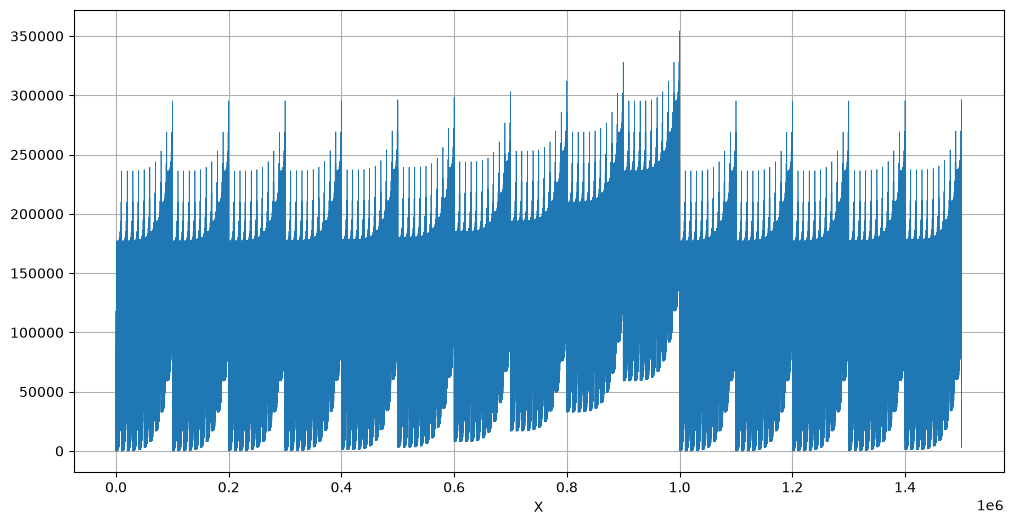

In [87]:
#check for the upper bound

import matplotlib.pyplot as plt
def f(x):
    return sum(int(c)**5 for c in str(x))
x = range(0, 1500001)
y = [f(i) for i in x]
plt.figure(figsize=(12, 6))
plt.plot(x, y, linewidth=0.5)
plt.xlabel("X")
plt.grid(True)

plt.show()

In [ ]:
# from the chart we see that it won't be higher than 6*9**5 = 354294 though I cannot be 100% sure 

354294


In [ ]:
#brute force 
ns_of_5th = []
for i in range(2,354295):
    cur_sum = f(i)
    if cur_sum == i:
        ns_of_5th.append(i) 
    

In [96]:
print(ns_of_5th)
print(sum(ns_of_5th))

[4150, 4151, 54748, 92727, 93084, 194979]
443839
